In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import classification_report

In [3]:
train_dir = "/content/drive/MyDrive/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/FruitinAmazon/test"


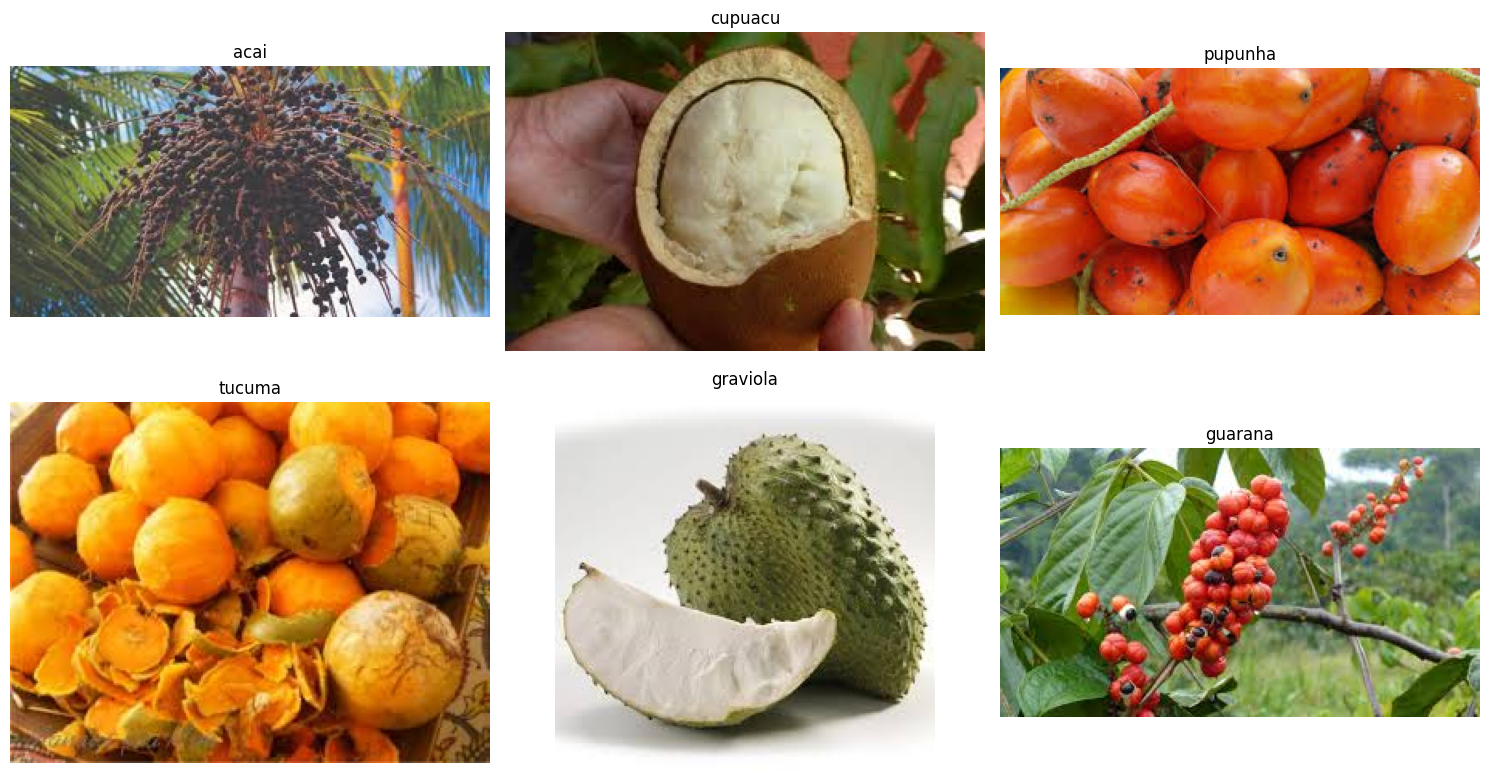

In [4]:
import random
def load_and_visualize_images(train):
    selected_images = []
    class_labels = []
    for class_dir in [d for d in os.listdir(train) if os.path.isdir(os.path.join(train, d))]:
        class_path = os.path.join(train, class_dir)
        images = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]

        if images:
            random_image = random.choice(images)
            selected_images.append(os.path.join(class_path, random_image))
            class_labels.append(class_dir)
    num_images = len(selected_images)
    cols = (num_images + 1) // 2

    fig, axes = plt.subplots(nrows=2, ncols=cols, figsize=(15, 8))
    axes = axes.flatten()
    for i, img_path in enumerate(selected_images):
        image = Image.open(img_path)
        axes[i].imshow(image)
        axes[i].set_title(class_labels[i])
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

load_and_visualize_images(train_dir)


The images are of different sizes as they are taken randomly.

In [9]:
def check_and_remove_corrupted_images(train):
    corrupted_images = []
    for class_dir in [d for d in os.listdir(train) if os.path.isdir(os.path.join(train, d))]:
        class_path = os.path.join(train, class_dir)

        images = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]

        for image_file in images:
            image_path = os.path.join(class_path, image_file)
            try:
                with Image.open(image_path) as img:
                    img.verify()
            except (IOError, SyntaxError) as e:
                os.remove(image_path)
                corrupted_images.append(image_path)
                print(f"Removed corrupted image: {image_path}")
    if not corrupted_images:
        print("No Corrupted Images Found.")
check_and_remove_corrupted_images(train_dir)


No Corrupted Images Found.


In [86]:
from tensorflow.keras.preprocessing import image_dataset_from_directory
img_height, img_width = 128, 128
batch_size = 32
validation_split = 0.2
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123,
    color_mode='rgb'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123,
    color_mode='rgb'
)
class_names = train_ds.class_names
print("Class Names:", class_names)


Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Class Names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [87]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [88]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", padding="same", strides=1, input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2), strides=2),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same", strides=1),
    layers.MaxPooling2D((2, 2), strides=2),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(6, activation="softmax")
])
model.summary()

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)                   │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_18 (MaxPooling2D)      │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 64, 64, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_19 (MaxPooling2D)      │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_9 (Flatten)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 64)                  │       2,097,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [89]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True)
]

history = model.fit(train_ds, validation_data=val_ds, epochs=250, batch_size=16, callbacks=callbacks)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.1250 - loss: 1.8859

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 589ms/step - accuracy: 0.1250 - loss: 1.8980 - val_accuracy: 0.0000e+00 - val_loss: 1.7829
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.2593 - loss: 1.7699

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 715ms/step - accuracy: 0.2639 - loss: 1.7593 - val_accuracy: 0.5000 - val_loss: 1.5950
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 737ms/step - accuracy: 0.3103 - loss: 1.6107 - val_accuracy: 0.3333 - val_loss: 1.6146
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.4572 - loss: 1.4170

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 520ms/step - accuracy: 0.4748 - loss: 1.4071 - val_accuracy: 0.7222 - val_loss: 1.3480
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.6302 - loss: 1.1224

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 570ms/step - accuracy: 0.6289 - loss: 1.1211 - val_accuracy: 0.7778 - val_loss: 0.9985
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 529ms/step - accuracy: 0.6827 - loss: 0.9568 - val_accuracy: 0.5000 - val_loss: 1.1772
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 458ms/step - accuracy: 0.7891 - loss: 0.7532 - val_accuracy: 0.3889 - val_loss: 1.2731
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.8090 - loss: 0.6088

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 513ms/step - accuracy: 0.9596 - loss: 0.1571 - val_accuracy: 0.8333 - val_loss: 0.4144
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 496ms/step - accuracy: 1.0000 - loss: 0.0850 - val_accuracy: 0.6667 - val_loss: 0.6784
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.9705 - loss: 0.0881

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 829ms/step - accuracy: 0.9674 - loss: 0.0888 - val_accuracy: 0.9444 - val_loss: 0.2734
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 1.0000 - loss: 0.0377

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 503ms/step - accuracy: 1.0000 - loss: 0.0366 - val_accuracy: 0.9444 - val_loss: 0.1912
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 516ms/step - accuracy: 0.9891 - loss: 0.0662 - val_accuracy: 0.8889 - val_loss: 0.2286
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 470ms/step - accuracy: 1.0000 - loss: 0.0163 - val_accuracy: 0.8333 - val_loss: 0.4670
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 754ms/step - accuracy: 1.0000 - loss: 0.0172 - val_accuracy: 0.8333 - val_loss: 0.4274
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 743ms/step - accuracy: 1.0000 - loss: 0.0124 - val_accuracy: 0.9444 - val_loss: 0.2556
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 1.0000 - loss: 0.0070

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 505ms/step - accuracy: 1.0000 - loss: 0.0070 - val_accuracy: 0.9444 - val_loss: 0.1564
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 1.0000 - loss: 0.0051

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 567ms/step - accuracy: 1.0000 - loss: 0.0051 - val_accuracy: 0.8889 - val_loss: 0.1524
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 539ms/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 0.8889 - val_loss: 0.2276
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 534ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 0.8889 - val_loss: 0.3281
Epoch 25/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 806ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.8889 - val_loss: 0.4039
Epoch 26/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 525ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.8889 - val_loss: 0.4541
Epoch 27/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 530ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.8889 - val_loss: 0.4747
Epoch 28/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 539ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.8889 - val_loss: 0.4688


In [90]:
test_loss, test_acc = model.evaluate(val_ds)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Validation Loss: {test_loss:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.8889 - loss: 0.1524
Test Accuracy: 0.8889
Validation Loss: 0.1524


In [91]:
model.save("SulokPandey_fruit.h5")
loaded_model= tf.keras.models.load_model("SulokPandey_fruit.h5")

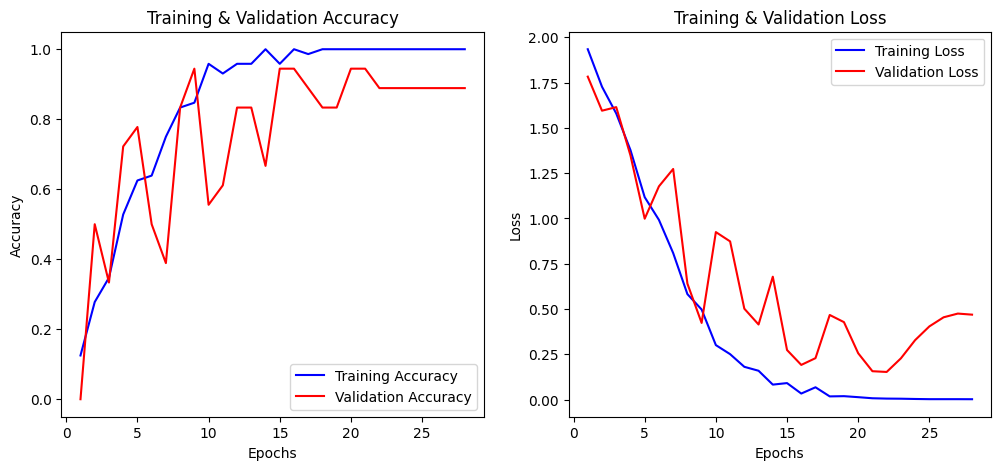

In [92]:
def plot_loss_accuracy(history):
    epochs = range(1, len(history.history['accuracy']) + 1)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['accuracy'], 'b-', label='Training Accuracy')
    plt.plot(epochs, history.history['val_accuracy'], 'r-', label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training & Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['loss'], 'b-', label='Training Loss')
    plt.plot(epochs, history.history['val_loss'], 'r-', label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training & Validation Loss')

    plt.show()

plot_loss_accuracy(history)

In [76]:
print("Unique class labels in validation dataset:", np.unique(val_labels))
print("Expected class names:", class_names)

Unique class labels in validation dataset: [4 5]
Expected class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [94]:
def get_dataset_arrays(dataset):
    images, labels = [], []
    for img_batch, label_batch in dataset:
        images.append(img_batch.numpy())
        labels.append(label_batch.numpy())
    return np.concatenate(images), np.concatenate(labels)

val_images, val_labels = get_dataset_arrays(val_ds)

pred_probs = model.predict(val_images)
pred_labels = np.argmax(pred_probs, axis=1)

unique_labels = np.unique(val_labels)

target_names = [class_names[i] for i in unique_labels]

report = classification_report(val_labels, pred_labels, target_names=target_names, labels=unique_labels)
print("Classification Report:\n", report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
Classification Report:
               precision    recall  f1-score   support

     pupunha       1.00      0.67      0.80         3
      tucuma       0.93      0.93      0.93        15

   micro avg       0.94      0.89      0.91        18
   macro avg       0.97      0.80      0.87        18
weighted avg       0.94      0.89      0.91        18



In [99]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
image_size = (128, 128)
class_names = sorted(os.listdir(test_dir))

test_images = []
test_labels = []

for label, class_name in enumerate(class_names):
    class_path = os.path.join(test_dir, class_name)
    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        image = load_img(image_path, target_size=image_size)
        image = img_to_array(image) / 255.0

        test_images.append(image)
        test_labels.append(label)

test_images = np.array(test_images)
test_labels = np.array(test_labels)

test_labels_onehot = tf.keras.utils.to_categorical(test_labels, num_classes=len(class_names))

predictions = loaded_model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(test_labels_onehot, axis=1)

report = classification_report(true_labels, predicted_labels, target_names=class_names)
print("Classification Report:\n", report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
Classification Report:
               precision    recall  f1-score   support

        acai       0.67      0.80      0.73         5
     cupuacu       0.67      0.40      0.50         5
    graviola       0.50      1.00      0.67         5
     guarana       0.75      0.60      0.67         5
     pupunha       0.80      0.80      0.80         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.67        30
   macro avg       0.73      0.67      0.66        30
weighted avg       0.73      0.67      0.66        30

